원본 p-value: 0.1776209982913241
1차 차분 p-value: 2.4234117859950287e-05


<Figure size 640x480 with 0 Axes>

c:\Users\a6742\anaconda3\envs\BigDataClass\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


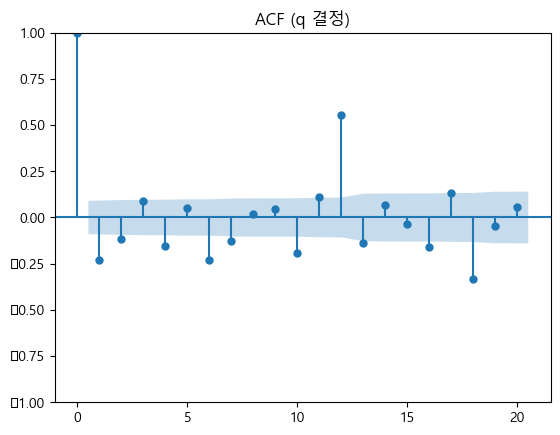

<Figure size 640x480 with 0 Axes>

c:\Users\a6742\anaconda3\envs\BigDataClass\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


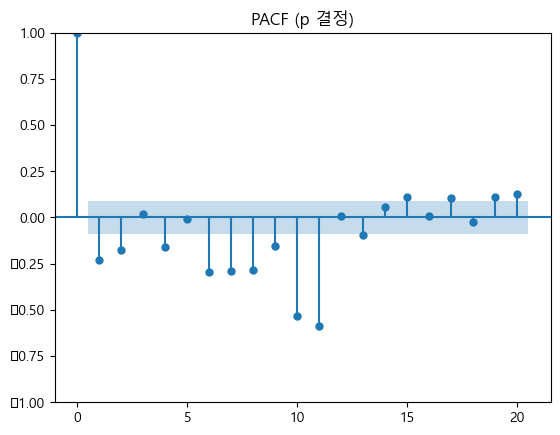

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import itertools

# (한글 폰트 설정 - 선택)
plt.rcParams['font.family'] = 'Malgun Gothic'

# 1) 데이터 불러오기
df = pd.read_csv("./data/beer.csv")
y = df['Monthly beer production']

# 2) 정상성 확인 (ADF Test)
result = adfuller(y) # 정상성 검증 test
print("원본 p-value:", result[1])  # 0.05보다 크면 정상성이 없다고 판단

# 3) 차분 적용 (d 결정) # 0
d=1
y_diff = y
for i in range(d):
    y_diff = y_diff.diff().dropna()

result_diff = adfuller(y_diff)
print("1차 차분 p-value:", result_diff[1])  # 0.05보다 작아지면 d=1 사용

# 4) ACF / PACF 그래프 (p, q 결정)
plt.figure()
plot_acf(y_diff, lags=20)
plt.title("ACF (q 결정)")
plt.show()

plt.figure()
plot_pacf(y_diff, lags=20)
plt.title("PACF (p 결정)")
plt.show()

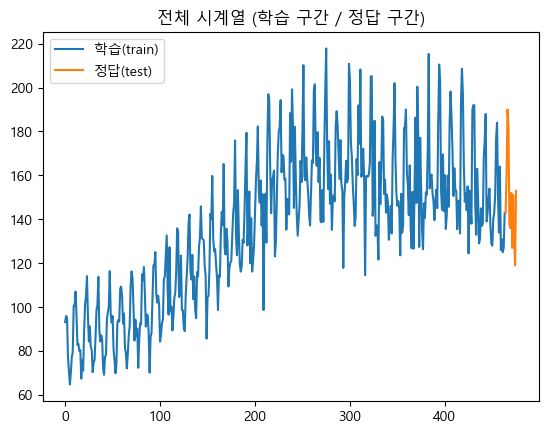

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.font_manager as fm
import numpy as np

df = pd.read_csv("./data/beer.csv")
y = df['Monthly beer production']

# 1) 정답(테스트) 미리 분리: 마지막 12개월을 테스트로
h = 12
y_train = y.iloc[:-h]
y_test  = y.iloc[-h:]   # ← 정답

# 2) 전체 흐름: 학습/정답 위치 확인
plt.figure()
plt.title("전체 시계열 (학습 구간 / 정답 구간)")
y_train.plot(label="학습(train)")
y_test.plot(label="정답(test)")
plt.legend()
plt.show()


c:\Users\a6742\anaconda3\envs\BigDataClass\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\a6742\anaconda3\envs\BigDataClass\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\a6742\anaconda3\envs\BigDataClass\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


RMSE = 8.197
MAPE = 4.74%


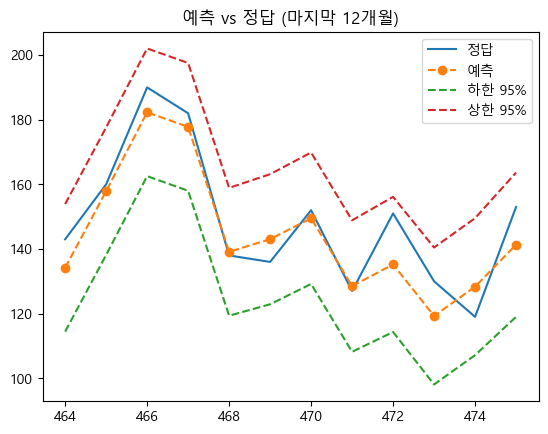

In [6]:

# 3) ARIMA 학습
model = ARIMA(y_train, order=(12,1,18))  
fit = model.fit()

# 4) 미래 예측
fc = fit.get_forecast(steps=h)
pred = fc.predicted_mean
ci   = fc.conf_int(alpha=0.05)
lower, upper = ci.iloc[:,0], ci.iloc[:,1]
pred.index = y_test.index
lower.index = y_test.index
upper.index = y_test.index

# 5) 성능 지표 (RMSE, MAPE)
rmse = float(np.sqrt(np.mean((y_test.values - pred.values)**2)))
mape = float(np.mean(np.abs((y_test.values - pred.values) / y_test.values))) * 100

print(f"RMSE = {rmse:.3f}")
print(f"MAPE = {mape:.2f}%")

# 6) 예측 vs 정답: 비교 집중
plt.figure()
plt.title("예측 vs 정답 (마지막 12개월)")
y_test.plot(label="정답")
pred.plot(label="예측", linestyle="--", marker="o")
lower.plot(linestyle="--", label="하한 95%")
upper.plot(linestyle="--", label="상한 95%")
plt.legend()
plt.show()

13:41:22 - cmdstanpy - INFO - Chain [1] start processing
13:41:22 - cmdstanpy - INFO - Chain [1] done processing


RMSE = 43.08, MAPE = 6.61%


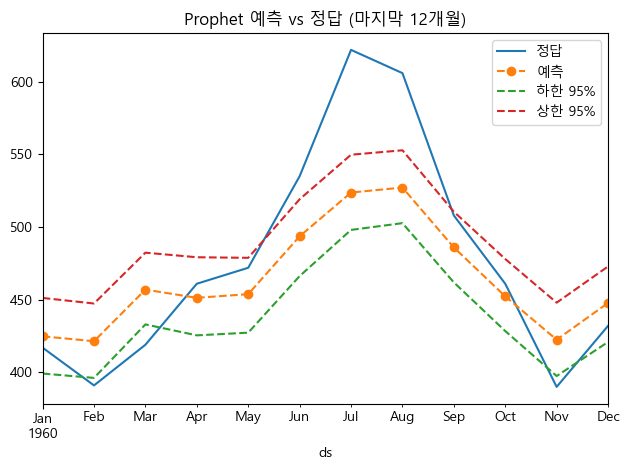

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

# (선택) 한글 폰트 — Windows/Mac 중 하나만 사용
plt.rcParams["font.family"] = "Malgun Gothic"  

# 1) AirPassengers 데이터 로드
df = pd.read_csv("./data/AirPassengers.csv", parse_dates=["Month"])
# Prophet 형식: ds, y
df = df.rename(columns={"Month": "ds", "#Passengers": "y"})  

# 2) 정답(테스트) 분리: 마지막 12개월
h = 12
train = df.iloc[:-h].copy()
test  = df.iloc[-h:].copy()

# 3) Prophet 모델 학습
m = Prophet(
    yearly_seasonality=True,  # 연간 계절성 (월별 데이터에 적합)
    weekly_seasonality=False,
    daily_seasonality=False
)
m.fit(train)

# 4) 미래 12개월 예측
future = m.make_future_dataframe(periods=h, freq="MS")  # 월단위(MS)
fcst = m.predict(future)

# 5) 테스트 구간만 추출 (예측/신뢰구간)
pred   = fcst.set_index("ds").loc[test["ds"]]
yhat   = pred["yhat"]
lower  = pred["yhat_lower"]
upper  = pred["yhat_upper"]

# 6) 간단 지표 (RMSE, MAPE)
import numpy as np
y_true = test.set_index("ds")["y"]
rmse = float(np.sqrt(np.mean((y_true - yhat)**2)))
mape = float(np.mean(np.abs((y_true - yhat) / y_true))) * 100
print(f"RMSE = {rmse:.2f}, MAPE = {mape:.2f}%")

# 7) 예측 vs 정답 + 95% 신뢰구간
plt.figure()
plt.title("Prophet 예측 vs 정답 (마지막 12개월)")
y_true.plot(label="정답")
yhat.plot(label="예측", linestyle="--", marker="o")
lower.plot(linestyle="--", label="하한 95%")
upper.plot(linestyle="--", label="상한 95%")
plt.legend(); plt.tight_layout(); plt.show()

In [13]:
# Grid-search ARIMA (p,d,q) to minimize RMSE on last 12 months
import itertools
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

# prepare series and train/test split (last 12 months as test)
h = 12
y = df['Monthly beer production']
y_train = y.iloc[:-h]
y_test = y.iloc[-h:]

# search ranges (small by default; expand if needed)
p_range = range(0,7)
d = 1
q_range = range(0,7)

best_rmse = np.inf
best_order = None
results = []

for p, q in itertools.product(p_range, q_range):
    try:
        model = ARIMA(y_train, order=(p,d,q))
        fit = model.fit()
        fc = fit.get_forecast(steps=h)
        pred = fc.predicted_mean
        # align index with test
        pred.index = y_test.index
        rmse = float(np.sqrt(np.mean((y_test.values - pred.values)**2)))
        results.append(((p,d,q), rmse))
        if rmse < best_rmse:
            best_rmse = rmse
            best_order = (p,d,q)
    except Exception:
        # skip non-invertible / convergence fails
        continue

print("검색한 모델 수:", len(results))
print("최적 order:", best_order, "RMSE:", best_rmse)

# show top 5
results_sorted = sorted(results, key=lambda x: x[1])[:5]
print("Top 5:")
for ordr, score in results_sorted:
    print(ordr, score)

# retrain best and plot
best_model = ARIMA(y_train, order=best_order).fit()
fc = best_model.get_forecast(steps=h)
pred = fc.predicted_mean
ci = fc.conf_int(alpha=0.05)
lower, upper = ci.iloc[:,0], ci.iloc[:,1]

plt.figure()
plt.title(f"Best ARIMA{best_order} Forecast vs Actual (RMSE={best_rmse:.3f})")
y_test.plot(label="Actual")
pred.plot(label="Forecast", linestyle="--", marker="o")
lower.plot(linestyle="--", label="Lower 95%")
upper.plot(linestyle="--", label="Upper 95%")
plt.legend(); plt.show()

# save results dataframe for inspection
res_df = pd.DataFrame([{"order":o, "rmse":r} for o, r in results])
res_df = res_df.sort_values('rmse').reset_index(drop=True)
res_df.head(10)

c:\Users\a6742\anaconda3\envs\BigDataClass\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\a6742\anaconda3\envs\BigDataClass\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\a6742\anaconda3\envs\BigDataClass\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\a6742\anaconda3\envs\BigDataClass\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters 

KeyboardInterrupt: 